In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import pickle, utils
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.patches as pat
from scipy.stats import bartlett, sem
from PIL import Image

In [2]:
with open('beh.pkl', 'rb') as f:
    beh = pickle.load(f)
with open("h_spike.pkl", "rb") as f:
    h = pickle.load(f)

In [3]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [4]:
T = 100
params = np.zeros((6, 3, T, 2, 5))
dist = np.zeros((6, 3, T, 2))
for mi in range(6):
    for di in range(3):
        pca = PCA(n_components=2, random_state=mi*10+di)
        tmp = pca.fit_transform(h[mi][di])
        print("mouse{} {} {:.1f}% explained".format(mi + 1, to_day(di), pca.explained_variance_ratio_.sum() * 100))
        p, d = utils.cmp_traj(tmp, beh[mi][di][:, 1:3], T=T, bias=49)
        params[mi, di, :, :, :] = p
        dist[mi, di, :, :] = d

mouse1 Day1 47.4% explained
mouse1 Day2 62.9% explained
mouse1 Day6 54.5% explained
mouse2 Day1 32.2% explained
mouse2 Day2 28.5% explained
mouse2 Day6 33.6% explained
mouse3 Day1 36.0% explained
mouse3 Day2 42.4% explained
mouse3 Day6 37.0% explained
mouse4 Day1 36.2% explained
mouse4 Day2 48.3% explained
mouse4 Day6 54.4% explained
mouse5 Day1 55.5% explained
mouse5 Day2 52.6% explained
mouse5 Day6 55.9% explained
mouse6 Day1 48.4% explained
mouse6 Day2 52.8% explained
mouse6 Day6 61.4% explained


In [5]:
def traj_img_name(mi, di, si, add_dirpath=False):
    s = ""
    if add_dirpath:
        s = s + "figures/fig6/fig6d/"
    return s + "mouse{}_{}_{}.png".format(mi + 1, to_day(di), "Success" if si == 0 else "Failure")

mouse1_Day1_Success.png


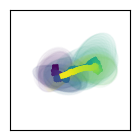

mouse1_Day1_Failure.png


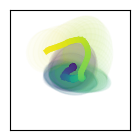

mouse1_Day2_Success.png


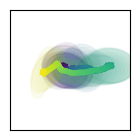

mouse1_Day2_Failure.png


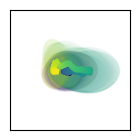

mouse1_Day6_Success.png


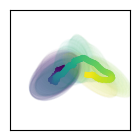

mouse1_Day6_Failure.png


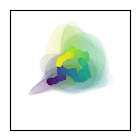

mouse2_Day1_Success.png


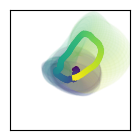

mouse2_Day1_Failure.png


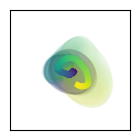

mouse2_Day2_Success.png


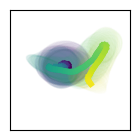

mouse2_Day2_Failure.png


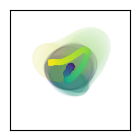

mouse2_Day6_Success.png


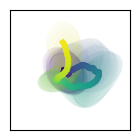

mouse2_Day6_Failure.png


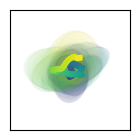

mouse3_Day1_Success.png


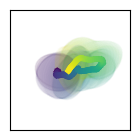

mouse3_Day1_Failure.png


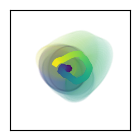

mouse3_Day2_Success.png


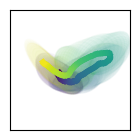

mouse3_Day2_Failure.png


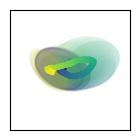

mouse3_Day6_Success.png


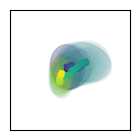

mouse3_Day6_Failure.png


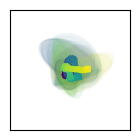

mouse4_Day1_Success.png


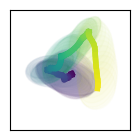

mouse4_Day1_Failure.png


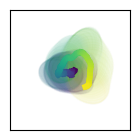

mouse4_Day2_Success.png


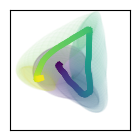

mouse4_Day2_Failure.png


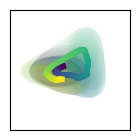

mouse4_Day6_Success.png


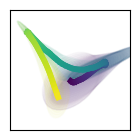

mouse4_Day6_Failure.png


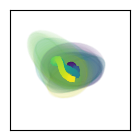

mouse5_Day1_Success.png


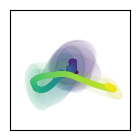

mouse5_Day1_Failure.png


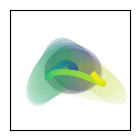

mouse5_Day2_Success.png


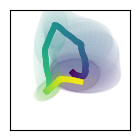

mouse5_Day2_Failure.png


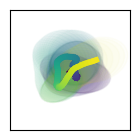

mouse5_Day6_Success.png


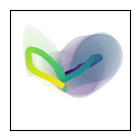

mouse5_Day6_Failure.png


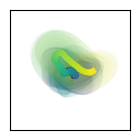

mouse6_Day1_Success.png


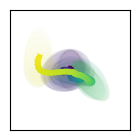

mouse6_Day1_Failure.png


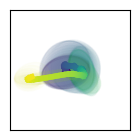

mouse6_Day2_Success.png


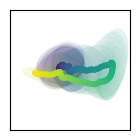

mouse6_Day2_Failure.png


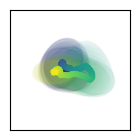

mouse6_Day6_Success.png


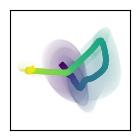

mouse6_Day6_Failure.png


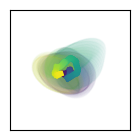

In [6]:
cmap = cm.viridis
for mi in range(6):
    for di in range(3):
        for si in range(2):
            plt.figure(figsize=(1.5, 1.5))
            ax = plt.subplot()
            for ti in range(T):
                x, y, a, b, theta = params[mi, di, ti, si, :]
                ax.add_patch(pat.Ellipse([x, y], a*2, b*2, angle=theta, alpha=0.025, color=cmap(ti/T), zorder=ti-100))
                if ti < T - 1:
                    ax.plot(params[mi, di, ti:ti+2, si, 0], params[mi, di, ti:ti+2, si, 1], color=cmap(ti/T), linewidth=4, zorder=ti+1)
            ax.set_xlim(-1, 1)
            ax.set_ylim(-1, 1)
            ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
            plt.tight_layout()
            print(traj_img_name(mi, di, si))
            plt.savefig(traj_img_name(mi, di, si, True))
            plt.show()

In [7]:
for mi in range(6):
    for di in range(3):
        for si in range(2):
            filename = traj_img_name(mi, di, si, True)
            im = Image.open(filename)
            im.crop((15, 15, 136, 136)).save(filename)

Day1: 0.1859 ± 0.0174
Day2: 0.2090 ± 0.0169
Day6: 0.2787 ± 0.0318
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  4.1259 2.0000 10.0000 0.0494

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2   0.0232 0.7617 -0.0617  0.108  False
  Day1   Day6   0.0928 0.0313   0.008 0.1777   True
  Day2   Day6   0.0697 0.1166 -0.0152 0.1545  False
---------------------------------------------------


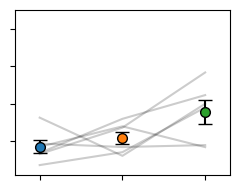

In [8]:
euc = dist[:, :, :, 0].mean(axis=-1)
plt.figure(figsize=(2.5, 2))
plt.plot(euc.T, color="k", alpha=0.2, zorder=0)
for di in range(3):
    y = euc[:, di].mean()
    yerr = sem(euc[:, di])
    print("{}: {:.4f} ± {:.4f}".format(to_day(di), y, yerr))
    plt.errorbar(x=di, y=y, yerr=yerr, fmt="o", ecolor='k', markeredgecolor = "k", color="C"+str(di), capsize=5, markersize=7, zorder=1)
plt.ylim(0.11, 0.55)
plt.xlim(-0.3, 2.3)
plt.yticks([0.2, 0.3, 0.4, 0.5])
plt.tick_params(labelbottom=False, labelleft=False)
plt.tight_layout()
plt.savefig("figures/fig6/fig6e.png")

df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "dist": euc.T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6)
})
anova = AnovaRM(df, depvar="dist", subject="mouse", within=["day"]).fit()
print(anova)
tukey = pairwise_tukeyhsd(endog=df["dist"], groups=df["day"], alpha=0.05)
print(tukey)

In [9]:
mahal = dist[:, :, :, 1].mean(axis=-1)
print(bartlett(mahal[:, 0], mahal[:, 1], mahal[:, 2]))

BartlettResult(statistic=10.593657946969953, pvalue=0.005007447506348812)


BartlettResult(statistic=1.9659273978785505, pvalue=0.3742004363933695)
Day1: -1.3058 ± 0.2086
Day2: -1.2318 ± 0.1590
Day6: -0.4496 ± 0.1061
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  6.8358 2.0000 10.0000 0.0135

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2    0.074 0.9453 -0.5261 0.6741  False
  Day1   Day6   0.8562 0.0056  0.2561 1.4563   True
  Day2   Day6   0.7822 0.0107  0.1821 1.3823   True
---------------------------------------------------


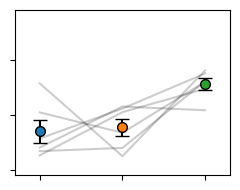

In [10]:
mahal = np.log(dist[:, :, :, 1]).mean(axis=-1)
print(bartlett(mahal[:, 0], mahal[:, 1], mahal[:, 2]))
plt.figure(figsize=(2.5, 2))
plt.plot(mahal.T, color="k", alpha=0.2, zorder=0)
for di in range(3):
    y=mahal[:, di].mean()
    yerr=sem(mahal[:, di])
    print("{}: {:.4f} ± {:.4f}".format(to_day(di), y, yerr))
    plt.errorbar(x=di, y=y, yerr=yerr, fmt="o", ecolor='k', markeredgecolor = "k", color="C"+str(di), capsize=5, markersize=7, zorder=1)
plt.ylim(-2.1, 0.9)
plt.xlim(-0.3, 2.3)
plt.yticks([-2, -1, 0])
plt.tick_params(labelbottom=False, labelleft=False)
plt.tight_layout()
plt.savefig("figures/fig6/fig6f.png")

df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "dist": mahal.T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6)
})
anova = AnovaRM(df, depvar="dist", subject="mouse", within=["day"]).fit()
print(anova)
tukey = pairwise_tukeyhsd(endog=df["dist"], groups=df["day"], alpha=0.05)
print(tukey)